In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

# I/O
io$outdir =  file.path(io$output.directory,"cluster_annotation")
dir.create(io$outdir, showWarnings = FALSE)

# args
args = list()
args$matrix = 'PeakMatrix'

addArchRThreads(12)
options(repr.plot.width=15, repr.plot.height=10)


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
       

In [3]:
metadata = as.data.frame(ArchRProject@cellColData)

In [8]:
# load rna metadata
rna_out = '/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/RNA/'
# load new metadata
celltypes = fread(paste0(rna_out, 'annotations_final.tsv')) %>%
     setnames(c('V1', 'assigned_celltype'), c('cell', 'celltype')) %>%
    .[order(match(cell, colnames(counts))),]
stages = fread(paste0(rna_out, 'metadata.csv')) %>%
    setnames('index', 'cell') %>%
     .[,c('cell', 'stage')] %>%
     .[order(match(cell, colnames(counts))),] 
meta_RNA = cbind(celltypes, stages[,2])

Warning message in fread(paste0(rna_out, "annotations_final.tsv")):
“Detected 1 column names but the data has 2 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [11]:
test =  fread(paste0(rna_out, 'metadata.csv'))

In [13]:
colnames(test)

[1] "index"            "sample"           "stage"            "batch"           
 [5] "doub.density"     "doublet"          "cluster"          "clustersub"      
 [9] "clusterstage"     "stripped"         "clusterIdx"       "clustercat"      
[13] "clusterSubUnique" "tsne1"            "tsne2"            "stage_res"       
[17] "ann_clusters"     "leiden"           "leiden_5"         "leiden_2"        
[21] "leiden_1"         "leiden_3"         "cell_id"          "cell_id_2"       
[25] "leiden_6"         "cell_id_l6"       "cell_id_6"        "cell_id_l6_test" 
[29] "celltype"

### Proportions per celltype

In [10]:
# Plot proportions
pdf1 = table(meta_RNA$celltype, meta_RNA$stage)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Var3 = 'RNA'

pdf2 = table(metadata$predictedGroup_celltype_PeakMatrix, metadata$stage)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Var3 = 'ATAC'

props = rbind(pdf1, pdf2)
props = props[,c('Var1', 'Var2', 'Var3', 'Freq')]
props$Freq = as.numeric(props$Freq)

options(repr.plot.width=15, repr.plot.height=15)
p = ggplot(props, aes(Var1, Freq, fill=Var3)) + 
    geom_bar(stat='identity', position = "dodge") + 
    facet_wrap(~Var2, ncol=1) + 
    theme_bw() + 
    ylab('Proportion') + 
    theme(axis.text.x=element_text(angle=-90, vjust=0, hjust=0),
          axis.title.x=element_blank(),
         text = element_text(size=20)) 

pdf(sprintf("%s/celltype_proportions.pdf",io$outdir), width=16, height=12)
print(p)
dev.off()

png 
  2

### Celltype annotation per cluster

In [16]:
# Plot cluster - celltype heatmap
pdf2 = table(metadata$predictedGroup_celltype_PeakMatrix, metadata$Clusters_PeakMatrix)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

test = dcast(pdf2, Var1 ~ Var2, value.var='Freq')
rownames(test) = test$Var1
test$Var1 = NULL
test <- scale(t(test))

ord <- hclust( dist(test, method = "euclidean"), method = "ward.D" )$order

pdf2$Var2 <- factor(pdf2$Var2, levels = rownames(test)[ord])

options(repr.plot.width=15, repr.plot.height=10)

p = ggplot(pdf2, aes(Var2, Var1, fill=Freq)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    theme(text=element_text(size = 15),
         axis.title = element_blank(),
         legend.position='none') 

pdf(sprintf("%s/celltype_per_cluster.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

Warning message in dcast(pdf2, Var1 ~ Var2, value.var = "Freq"):
“The dcast generic in data.table has been passed a data.frame and will attempt to redirect to the reshape2::dcast; please note that reshape2 is deprecated, and this redirection is now deprecated as well. Please do this redirection yourself like reshape2::dcast(pdf2). In the next version, this warning will become an error.”


png 
  2

In [18]:
# Plot cluster - celltype heatmap
pdf2 = table(metadata$predictedGroup_celltype_PeakMatrix, metadata$stage_clusters)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

test = dcast(pdf2, Var1 ~ Var2, value.var='Freq')
rownames(test) = test$Var1
test$Var1 = NULL
test <- scale(t(test))

ord <- hclust( dist(test, method = "euclidean"), method = "ward.D" )$order

pdf2$Var2 <- factor(pdf2$Var2, levels = rownames(test)[ord])

options(repr.plot.width=15, repr.plot.height=10)

p = ggplot(pdf2, aes(Var2, Var1, fill=Freq)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    theme(text=element_text(size = 15),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0),
         axis.title = element_blank(),
         legend.position='none') 

pdf(sprintf("%s/celltype_per_stagecluster.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

Warning message in dcast(pdf2, Var1 ~ Var2, value.var = "Freq"):
“The dcast generic in data.table has been passed a data.frame and will attempt to redirect to the reshape2::dcast; please note that reshape2 is deprecated, and this redirection is now deprecated as well. Please do this redirection yourself like reshape2::dcast(pdf2). In the next version, this warning will become an error.”


png 
  2

In [19]:
order = as.data.frame(metadata) %>% 
    arrange(predictedGroup_celltype_PeakMatrix, predictedScore_celltype_PeakMatrix) %>% 
    .$cell

In [20]:
p = ggplot(metadata, aes(factor(cell, levels = order), predictedGroup_celltype_PeakMatrix, fill = predictedScore_celltype_PeakMatrix)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    scale_color_viridis() + 
    labs(x = 'cells', y = 'Predicted celltype', fill = 'Score') +
    theme_classic() + 
    theme(text = element_text(color='black', size = 15),
          axis.text.x = element_blank())

pdf(sprintf("%s/score_per_celltype.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

png 
  2

# Label Clusters

In [353]:
cluster_anno = as.data.frame(table(metadata$stage_clusters, metadata$predictedGroup_celltype_PeakMatrix)) %>% filter(Freq>0) %>% arrange(Var1, -Freq)
write.csv(cluster_anno, sprintf('%s/cluster_annotation.csv', io$outdir))

In [354]:
annos = as.data.table(metadata) %>% 
    .[,.(mean(predictedScore_celltype_PeakMatrix), .N), by=.(stage_clusters, predictedGroup_celltype_PeakMatrix)] %>%
    .[,prop:=N/sum(N), by=stage_clusters] %>%
    setnames('V1', 'mean_score')

In [355]:
length(unique(annos$stage_clusters))

[1] 78

In [358]:
score_thr = 0.55
prop_thr = 0.50
anno_labelled = annos[annos[, .I[which.max(prop)], by=stage_clusters]$V1] %>%    # Select celltype with highest proportion for each cluster
    .[,celltype:= ifelse(mean_score>score_thr, predictedGroup_celltype_PeakMatrix, paste0(predictedGroup_celltype_PeakMatrix, "_?"))] %>%   # Add _? if score is low    
    .[,celltype:= ifelse(prop>prop_thr, celltype, 'unknown')] %>% # if prop > 0.7 annotate celltype    
    .[match(ArchRProject@cellColData$stage_clusters, stage_clusters)] %>% .$celltype # put in order of ArchR metdata
ArchRProject@cellColData$celltype_v1 = anno_labelled

Length of unique values greater than palette, interpolating..

Length of unique values greater than palette, interpolating..



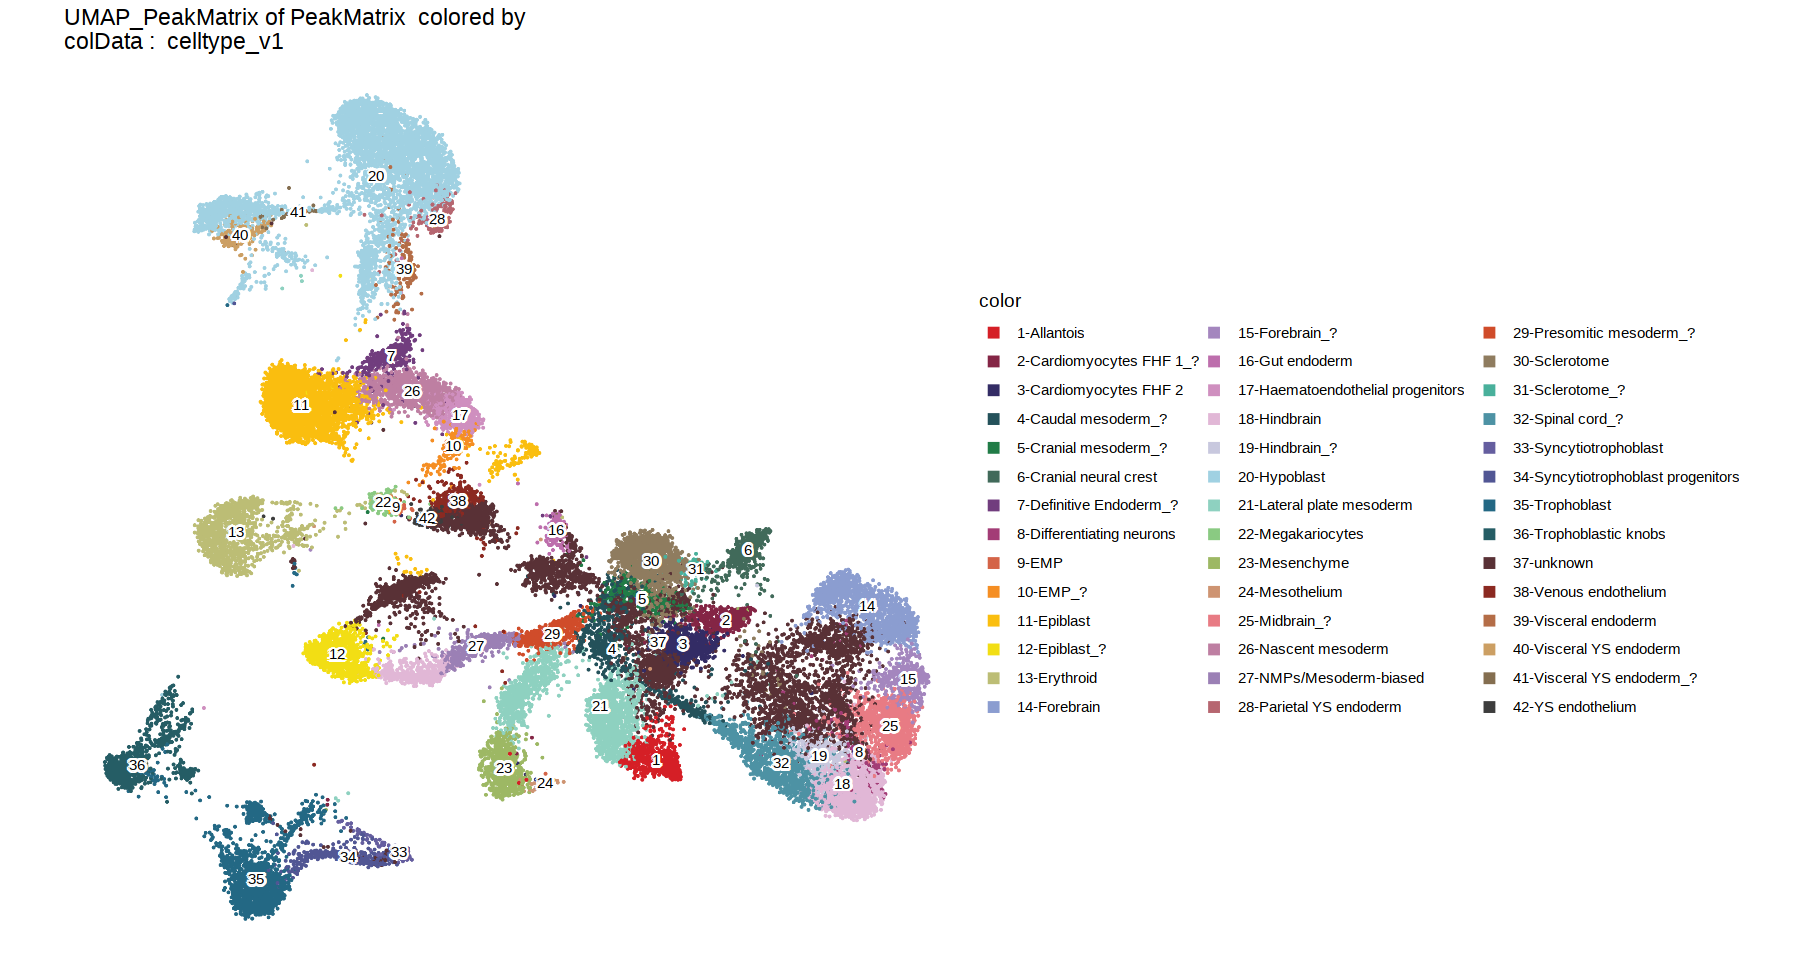

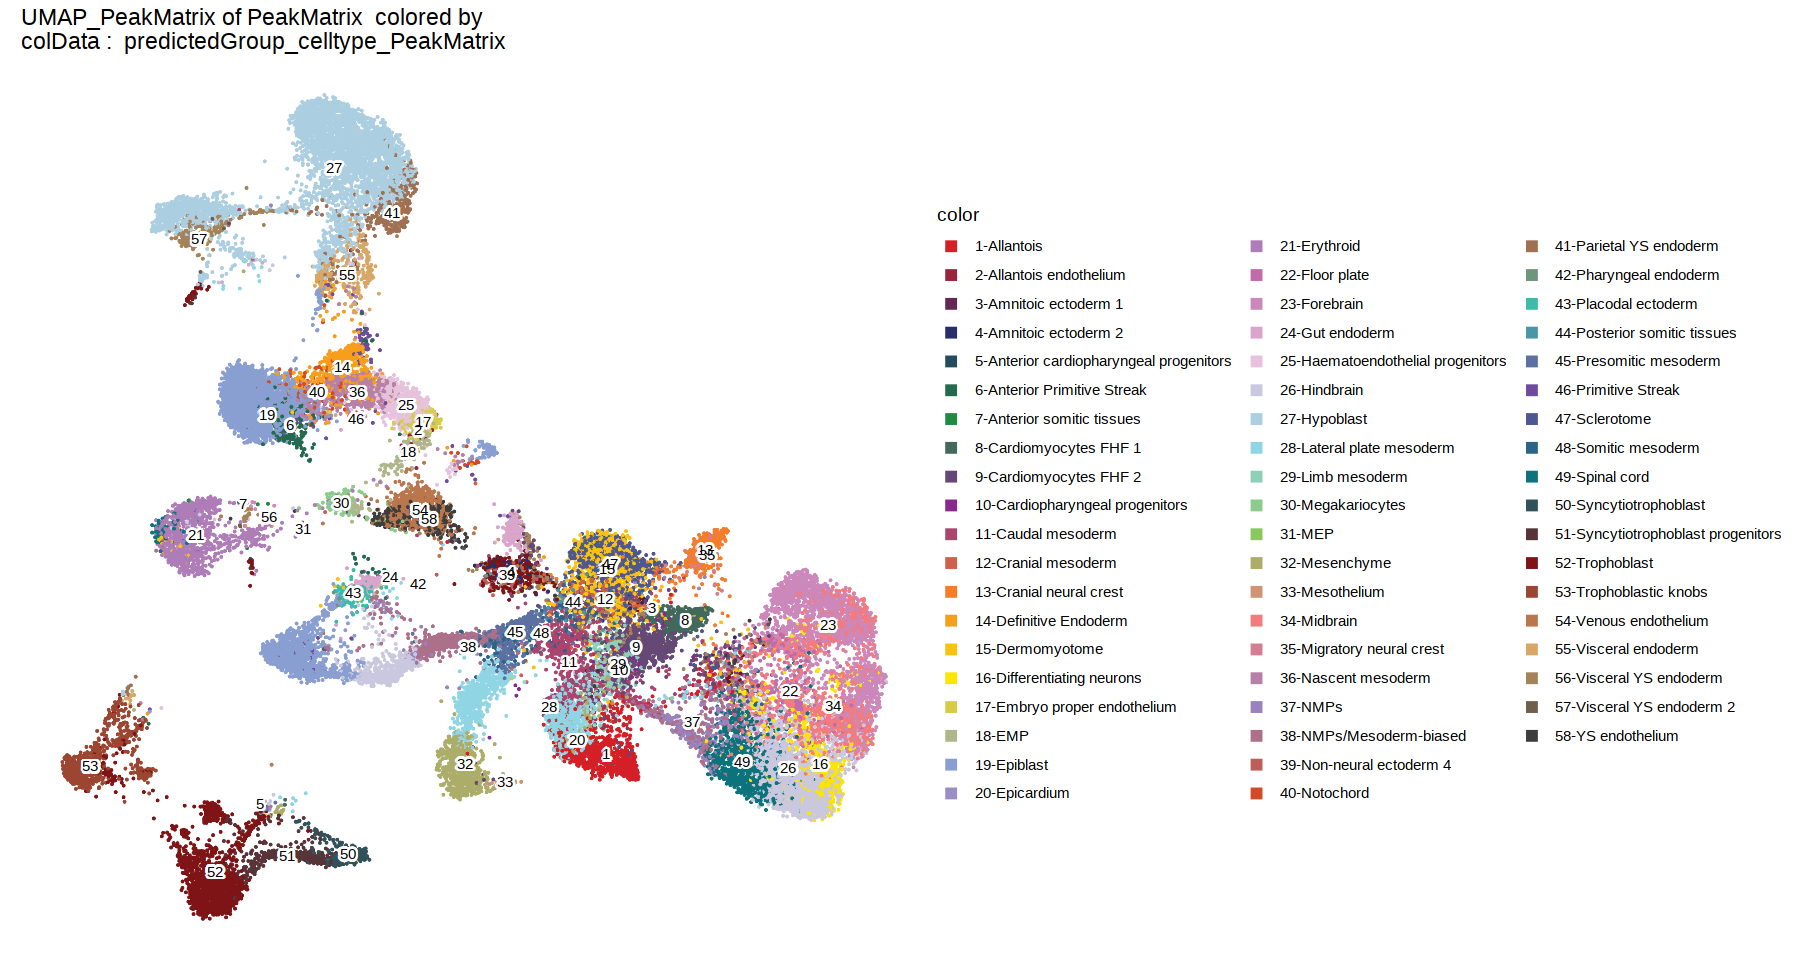

In [359]:
plotEmbedding(
  ArchRProj = ArchRProject,
  embedding = "UMAP_PeakMatrix",
  colorBy = "cellColData",
  name = "celltype_v1") + theme_void()

plotEmbedding(
  ArchRProj = ArchRProject,
  embedding = "UMAP_PeakMatrix",
  colorBy = "cellColData",
  name = "predictedGroup_celltype_PeakMatrix") + theme_void()

In [360]:
archr_meta = as.data.frame(getCellColData(ArchRProject))

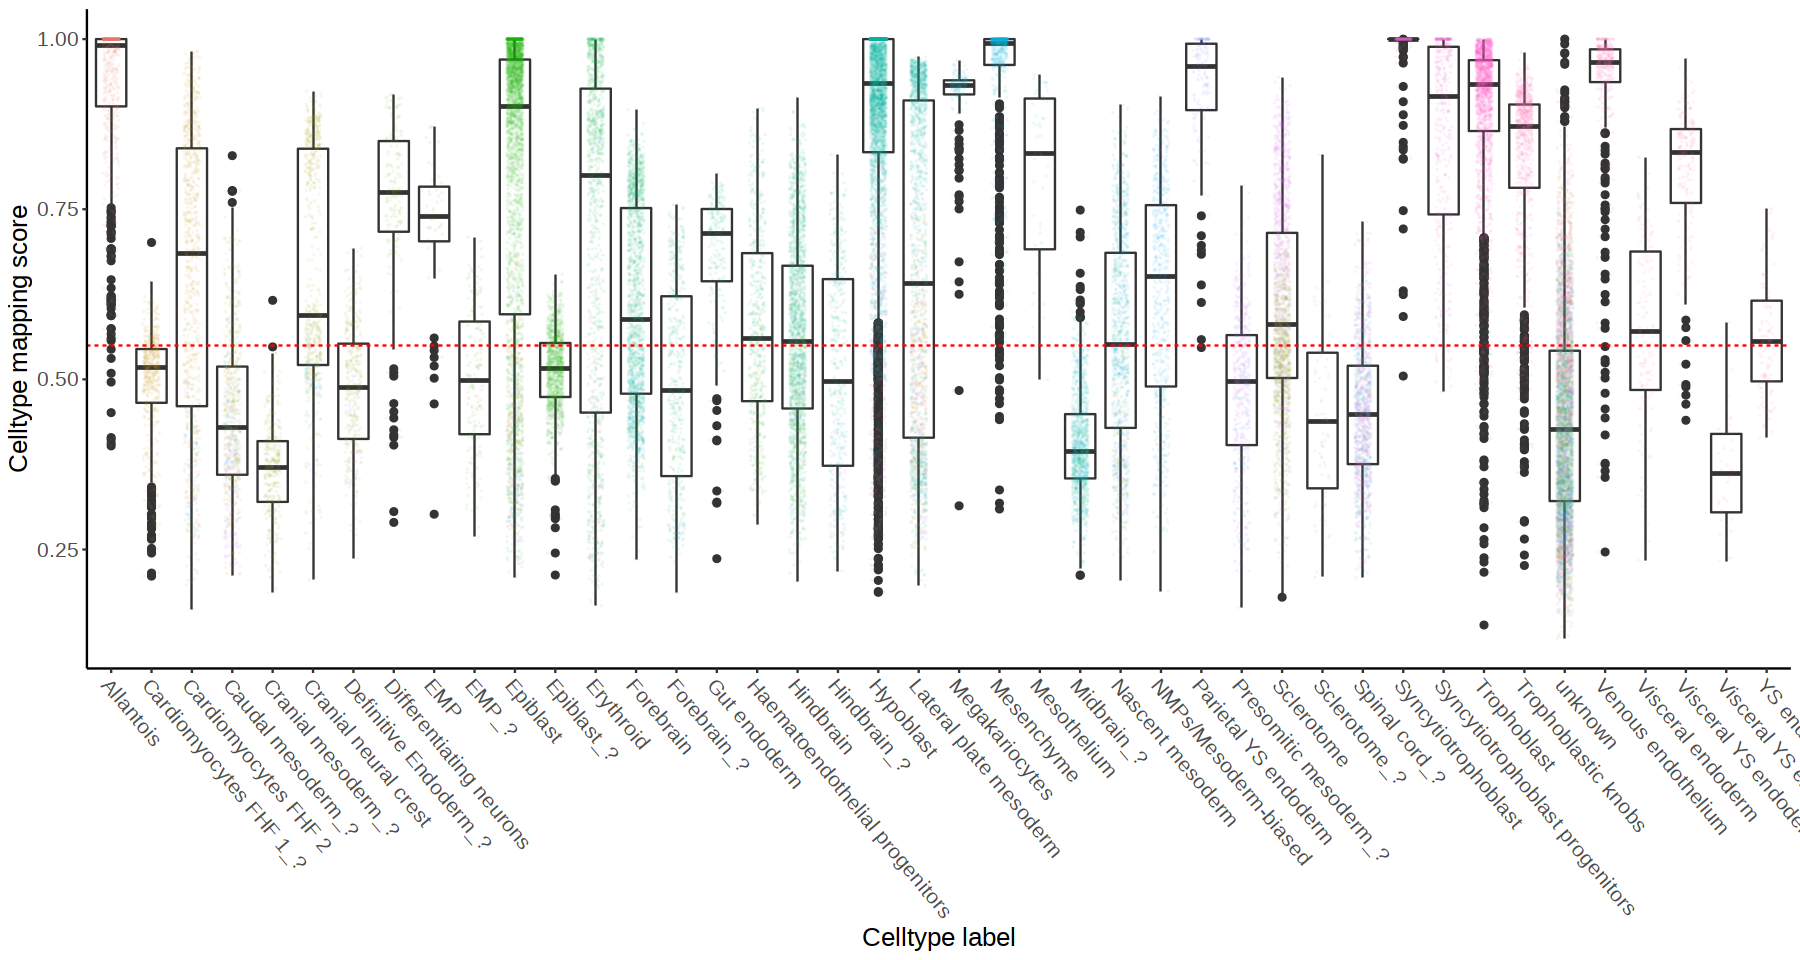

In [361]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(archr_meta, aes(celltype_v1, predictedScore_celltype_PeakMatrix)) + 
        geom_boxplot() + 
        geom_jitter(position=position_jitter(0.2), size = 0.001, alpha = 0.05, aes(col=predictedGroup_celltype_PeakMatrix)) + 
        xlab('Celltype label') + ylab('Celltype mapping score') + 
        geom_hline(yintercept=score_thr, linetype = 'dashed', col='red') +
        theme_classic() + theme(text = element_text(size=15, color='black'),
                                axis.text.x=element_text(angle=-50, hjust=0),
                               legend.position='none')

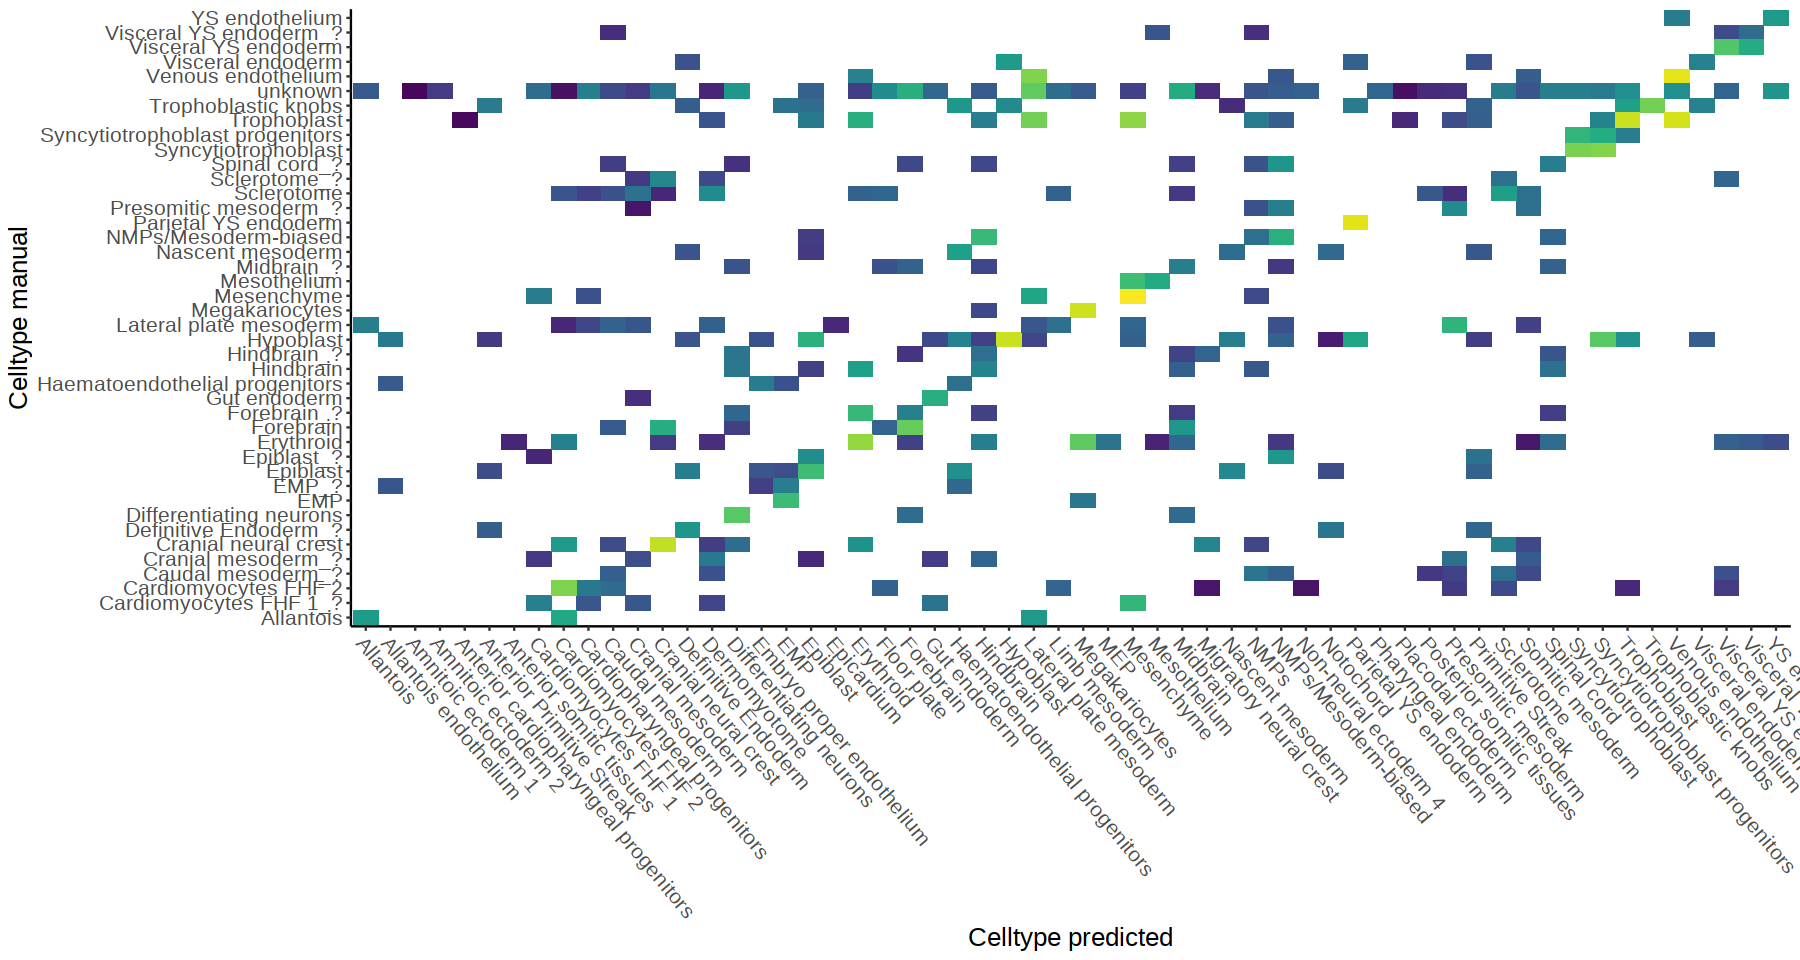

In [362]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(archr_meta, aes(predictedGroup_celltype_PeakMatrix, celltype_v1,  fill=predictedScore_celltype_PeakMatrix)) + 
        geom_tile() +
        scale_fill_viridis() +
        xlab('Celltype predicted') + ylab('Celltype manual') + 
        theme_classic() + theme(text = element_text(size=15, color='black'),
                                axis.text.x=element_text(angle=-50, hjust=0),
                               legend.position='none')

In [363]:
pdf1 = table(archr_meta$predictedGroup_celltype_PeakMatrix, archr_meta$celltype_v1)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

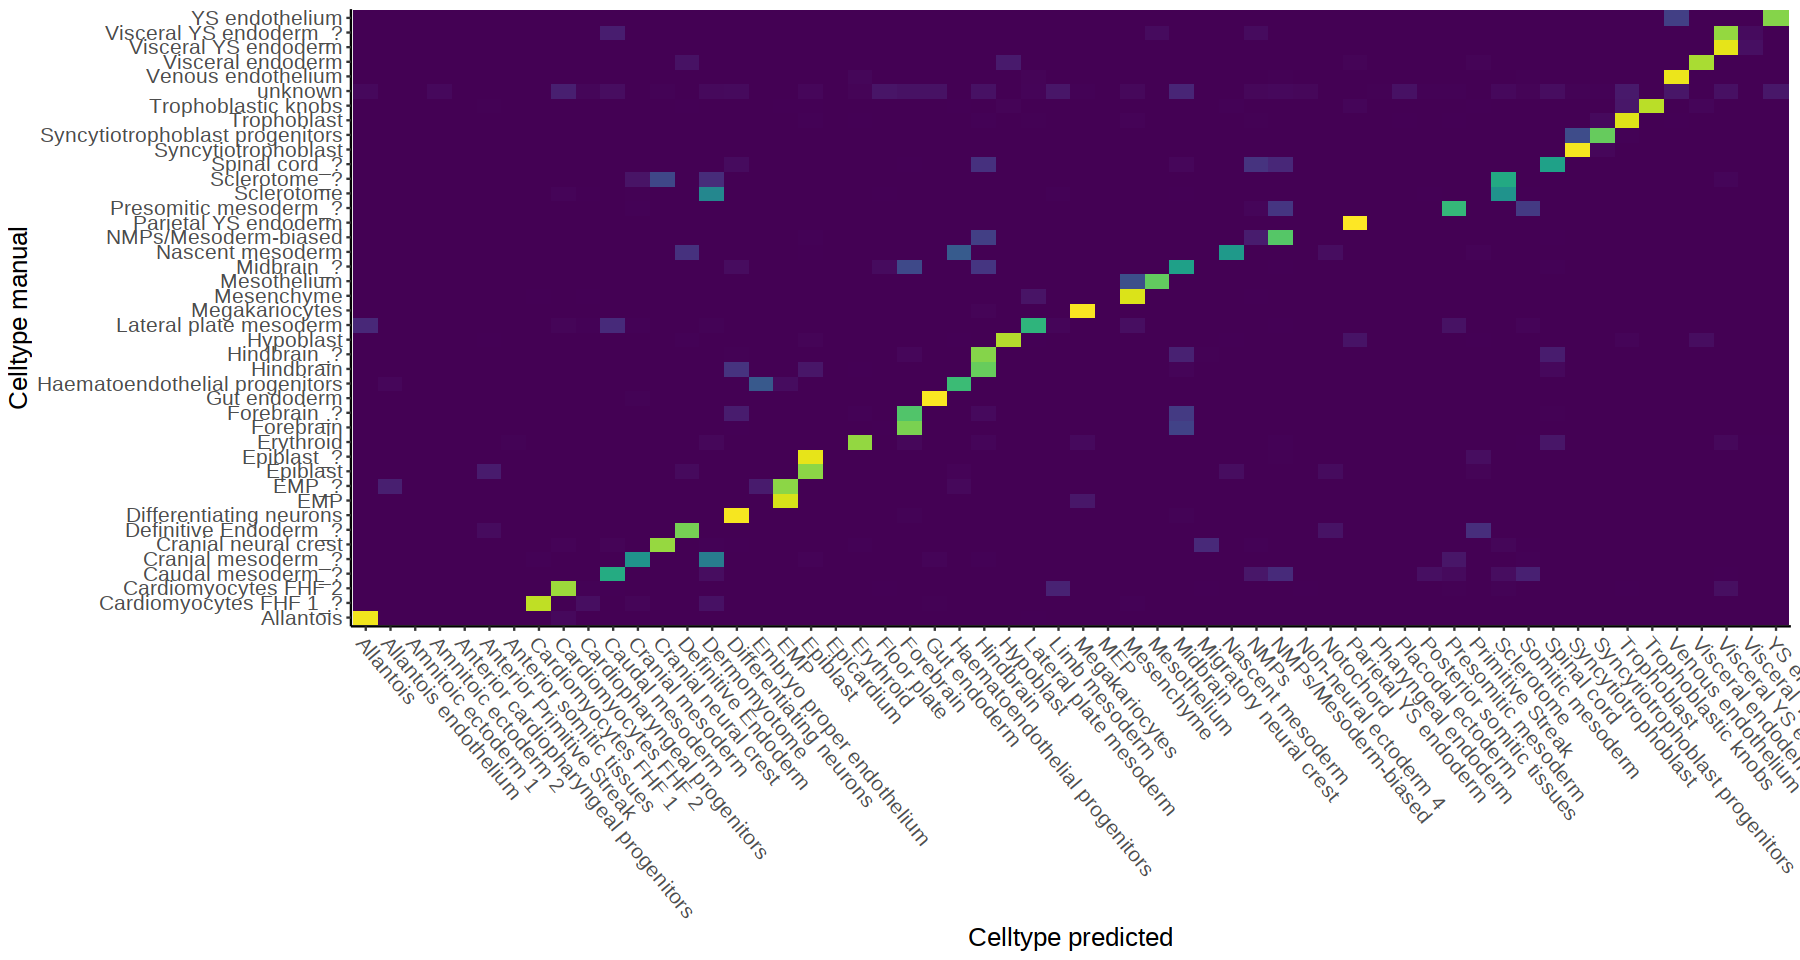

In [364]:
ggplot(pdf1, aes(Var1, Var2,  fill=Freq)) + 
        geom_tile() +
        scale_fill_viridis() +
        xlab('Celltype predicted') + ylab('Celltype manual') + 
        theme_classic() + theme(text = element_text(size=15, color='black'),
                                axis.text.x=element_text(angle=-50, hjust=0),
                               legend.position='none')

In [365]:
saveArchRProject(ArchRProj = ArchRProject)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(30): sample Sample ... celltype_v1 celltype_v1_tile
numberOfCells(1): 37157
medianTSS(1): 3.605
medianFrags(1): 34347

## Find markers per celltype

In [52]:
getAvailableMatrices(ArchRProject)

[1] "GeneIntegrationMatrix_PeakMatrix" "GeneIntegrationMatrix_TileMatrix"
[3] "GeneScoreMatrix"                  "MotifMatrix"                     
[5] "PeakMatrix"                       "TileMatrix"

In [71]:
find_markers = function(matrix, FDR=0.05, log2FC=1.25, ntop=4){
    markers <- getMarkerFeatures(
        ArchRProj = ArchRProject, 
        useMatrix = matrix, 
        groupBy = "celltype_v1",
        bias = c("TSSEnrichment", "log10(nFrags)"),
        testMethod = "wilcoxon"
    )
    saveRDS(markers, file.path(io$outdir, sprintf('markers_%s.rds', matrix)))

    heatmapGS <- plotMarkerHeatmap(
        seMarker = markers, 
        cutOff = sprintf("FDR <= %s & Log2FC >= %s", FDR, log2FC),
      nLabel = ntop,
      nPrint = ntop
    )

    options(repr.plot.width=15, repr.plot.height=8)
    ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")
    plotPDF(heatmapGS, name = paste0('heatmap_', matrix), width = 9, height = 40, ArchRProj = ArchRProject, addDOC = FALSE)   
}

 [1] "chr1:3745039-3745639"      "chr1:5559129-5559729"     
 [3] "chr1:728101-728701"        "chr1:7157281-7157881"     
 [5] "chr1:15347786-15348386"    "chr1:71294163-71294763"   
 [7] "chr1:56732913-56733513"    "chr1:66323871-66324471"   
 [9] "chr12:119336617-119337217" "chr7:55776236-55776836"   
[11] "chr1:615580-616180"        "chr1:2015421-2016021"     
[13] "chr1:149066211-149066811"  "chr10:22519667-22520267"  
[15] "chr1:15758342-15758942"    "chr1:69189868-69190468"   
[17] "chr1:71-671"               "chr1:1507-2107"           
[19] "chr1:92400210-92400810"    "chr3:144031557-144032157" 
[21] "chr1:151469-152069"        "chr1:514857-515457"       
[23] "chr1:3054890-3055490"      "chr1:3072723-3073323"     
[25] "chr1:565325-565925"        "chr1:622402-623002"       
[27] "chr1:3754392-3754992"      "chr1:4947349-4947949"     
[29] "chr1:7916220-7916820"      "chr1:8181196-8181796"     
[31] "chr1:129200034-129200634"  "chr1:174984048-174984648" 
[33] "chr1:3347484-33480

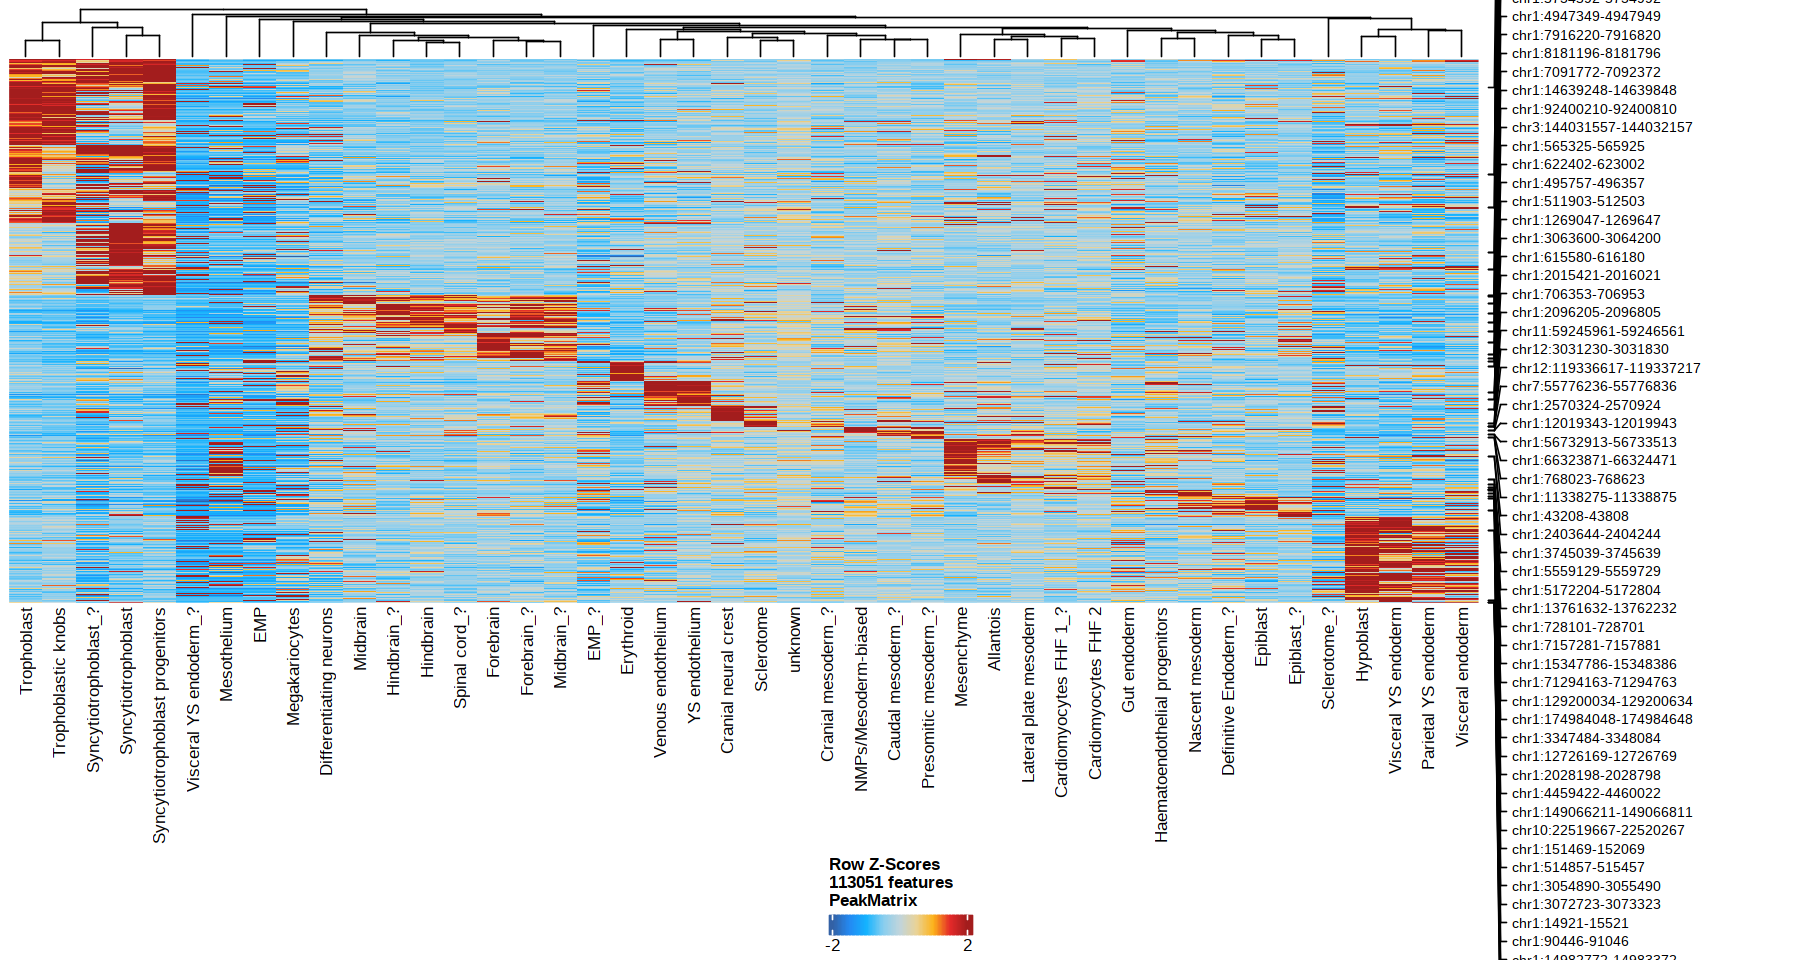

In [54]:
# Markers PeakMatrix
suppressMessages(find_markers('PeakMatrix', ntop=2))

  [1] "chr1:ENSOCUG00000033576"  "chr10:HOXA11"            
  [3] "chr10:COL1A2"             "chr12:ENSOCUG00000006836"
  [5] "chr1:ENSOCUG00000012976"  "chr10:ENSOCUG00000031765"
  [7] "chr14:POPDC2"             "chr17:ocu-mir-208a"      
  [9] "chr1:ENSOCUG00000020925"  "chr1:ENSOCUG00000027054" 
 [11] "chr1:ENSOCUG00000037885"  "chr1:OR8U3"              
 [13] "chr10:HOXA7"              "chr19:HOXB9"             
 [15] "chr19:ENSOCUG00000036354" "chr19:HOXB3"             
 [17] "chr16:ENSOCUG00000039059" "chr1:SNX30"              
 [19] "chr1:PTBP3"               "chr1:SUSD1"              
 [21] "chr1:PATE2"               "chr17:SNORD115"          
 [23] "chr9:ORYCUNV1R1629"       "chr14:THPO"              
 [25] "chr15:ENSOCUG00000035595" "chr15:ENSOCUG00000000482"
 [27] "chr9:ENSOCUG00000021347"  "chr1:ENSOCUG00000019595" 
 [29] "chr10:PPP1R17"            "chr11:ENSOCUG00000030824"
 [31] "chr12:ENSOCUG00000019212" "chr1:ENSOCUG00000021292" 
 [33] "chr1:SLC43A3"             "chr11:

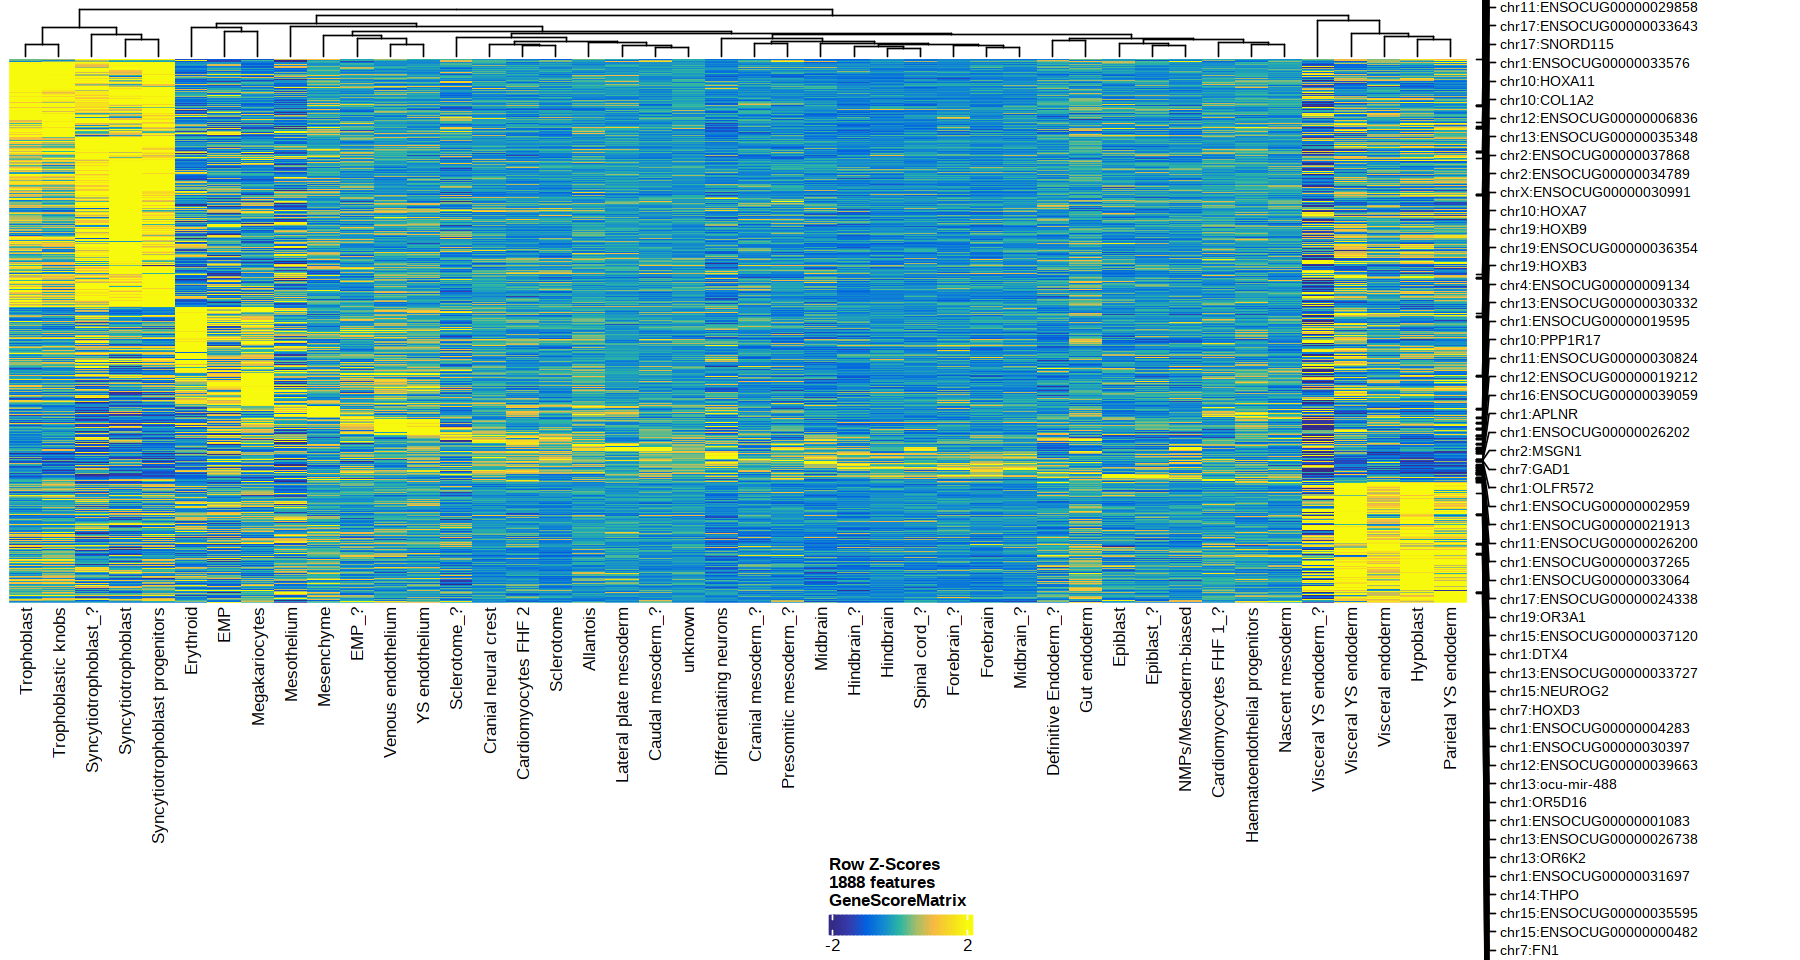

In [55]:
# Markers GeneScoreMatrix
suppressMessages(find_markers('GeneScoreMatrix', ntop=4))

  [1] "chr1:NANS"                "chr1:ENSOCUG00000023438" 
  [3] "chr1:SRPRA"               "chr1:CCDC83"             
  [5] "chr1:ENSOCUG00000018624"  "chr1:ENSOCUG00000006972" 
  [7] "chr1:ENSOCUG00000011876"  "chr1:ALG8"               
  [9] "chr1:ENSOCUG00000025387"  "chr1:ANKS6"              
 [11] "chr1:MSMP"                "chr1:ENSOCUG00000036685" 
 [13] "chr1:ENSOCUG00000035965"  "chr1:ENSOCUG00000037727" 
 [15] "chr1:ENSOCUG00000032122"  "chr10:ENSOCUG00000035635"
 [17] "chr1:C11orf65"            "chr1:OR10A3"             
 [19] "chr1:ENSOCUG00000029350"  "chr11:ENSOCUG00000022356"
 [21] "chr1:ATM"                 "chr1:ENSOCUG00000037184" 
 [23] "chr1:ENSOCUG00000024880"  "chr11:KIAA0825"          
 [25] "chr1:FRMPD1"              "chr1:IFT74"              
 [27] "chr1:LRRC19"              "chr1:ENSOCUG00000033737" 
 [29] "chr1:RGP1"                "chr1:CEMIP2"             
 [31] "chr1:ABHD17B"             "chr1:ENSOCUG00000023077" 
 [33] "chr1:UHRF2"               "chr1:P

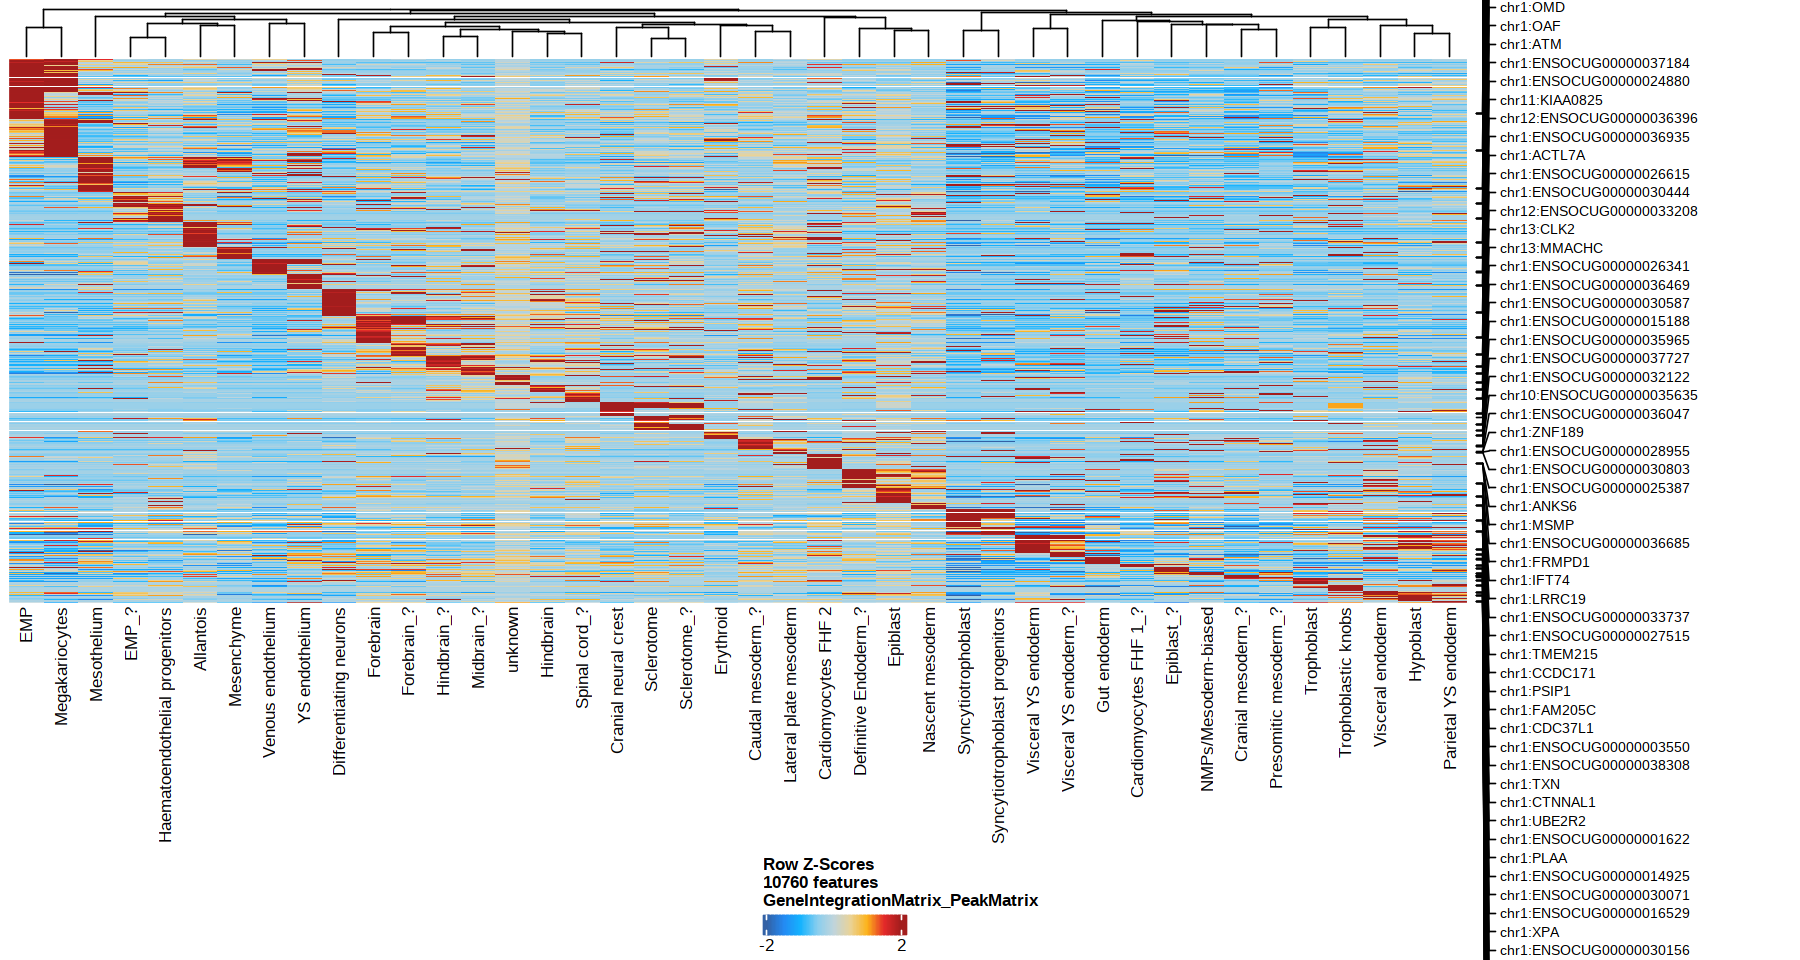

In [367]:
# Markers GeneScoreMatrix
suppressMessages(find_markers('GeneIntegrationMatrix_PeakMatrix', ntop=4))

In [434]:
# Plot markers of geneIntegration Matrix
markers = readRDS( file.path(io$outdir, sprintf('markers_%s.rds', 'GeneIntegrationMatrix_PeakMatrix')))

plot_volcano = function(celltype, n=25, FDR_thr=0.01, LogFC_thr = 1.25){
    
    ct_markers = markers[,colnames(markers)== celltype]
    ct_markers = ct_markers[order(-abs(ct_markers@assays@data$Log2FC))]

    to.plot = data.table(x = ct_markers@assays@data$Log2FC, y = ct_markers@assays@data$FDR, name=rowData(ct_markers)$name) %>%
        setnames(c('x.x', 'y.x'), c('LogFC', 'FDR')) %>% 
        .[,name:= gsub('ENSOCUG000000', 'ID_', name)] %>%
        .[,Diff:=ifelse(LogFC>LogFC_thr & FDR<FDR_thr, 'Up', ifelse(LogFC<=-LogFC_thr & FDR<FDR_thr, 'Down', 'non'))]

    ggplot(to.plot[abs(LogFC)>0,], aes(LogFC, -log10(FDR), col=Diff)) + 
        geom_point() + 
        scale_color_manual(values=c('blue', 'gray70', 'red'), name='Significant') + 
        geom_hline(yintercept = -log10(FDR_thr), linetype = 'dashed', color = 'gray30') +
        geom_vline(xintercept = c(-LogFC_thr, LogFC_thr), linetype = 'dashed', color = 'gray30') +
        geom_vline(xintercept = 0, linetype = 'dashed', color = 'black') +
        ggtitle(celltype,
               sprintf('Down: %d, Up: %d', nrow(to.plot[Diff=='Down', ]), nrow(to.plot[Diff=='Up', ]))) + 
        ggrepel::geom_label_repel(data=to.plot[LogFC<LogFC_thr & FDR<=FDR_thr,][!grep('ID_', name),] %>% top_n(n, -LogFC), 
                                    aes(LogFC, -log10(FDR), label=name),
                                    max.overlaps=Inf,
                                    box.padding = 0.3) + 
        ggrepel::geom_label_repel(data=to.plot[LogFC>LogFC_thr & FDR<=FDR_thr ,][!grep('ID_', name),] %>% top_n(n, LogFC), 
                                    aes(LogFC, -log10(FDR), label=name),
                                    max.overlaps=Inf,
                                    box.padding = 0.3) +
        theme_bw() + 
        theme(text=element_text(size=15, color='black'), 
              legend.position='none')
}

In [435]:
celltypes = unique(ArchRProject@cellColData$celltype_v1)

In [437]:
pdf(file.path(io$outdir, 'volcano_plots_celltype_v1.pdf'), width=10, height=9)
lapply(celltypes, plot_volcano)
dev.off()

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data fra

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]

[[12]]

[[13]]

[[14]]

[[15]]

[[16]]

[[17]]

[[18]]

[[19]]

[[20]]

[[21]]

[[22]]

[[23]]

[[24]]

[[25]]

[[26]]

[[27]]

[[28]]

[[29]]

[[30]]

[[31]]

[[32]]

[[33]]

[[34]]

[[35]]

[[36]]

[[37]]

[[38]]

[[39]]

[[40]]

[[41]]

[[42]]


png 
  2

In [438]:
matrix = 'GeneIntegrationMatrix_PeakMatrix'
markers <- getMarkerFeatures(
    ArchRProj = ArchRProject, 
    useMatrix = matrix, 
    groupBy = "stage_clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon")

In [439]:
markers

class: SummarizedExperiment 
dim: 20793 78 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(20793): 1 2 ... 20792 20793
rowData names(6): seqnames start ... name idx
colnames(78): GD7_C1 GD7_C2 ... GD9_ExE_C12 GD9_ExE_C13
colData names(0):

In [440]:
stage_clusters = unique(ArchRProject@cellColData[ArchRProject@cellColData$celltype_v1=='unknown',]$stage_clusters)
    
pdf(file.path(io$outdir, 'volcano_plots_stage_clusters_unknown.pdf'), width=10, height=9)
    lapply(stage_clusters, plot_volcano)
dev.off()

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”
Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]


png 
  2

In [369]:
colors = 'celltype_v1'


    # Fetch UMAP coordinates
    umap.dt <- getEmbedding(ArchRProject,paste0("UMAP_PeakMatrix")) %>%
      round(2) %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))

        # Plot
    sample_metadata = as.data.frame(getCellColData(ArchRProject))
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")

labels = to.plot[,list(median(umap1), median(umap2)), 
                                  by= colors] %>%
        setnames(c('V1', 'V2'), c('umap1', 'umap2'))

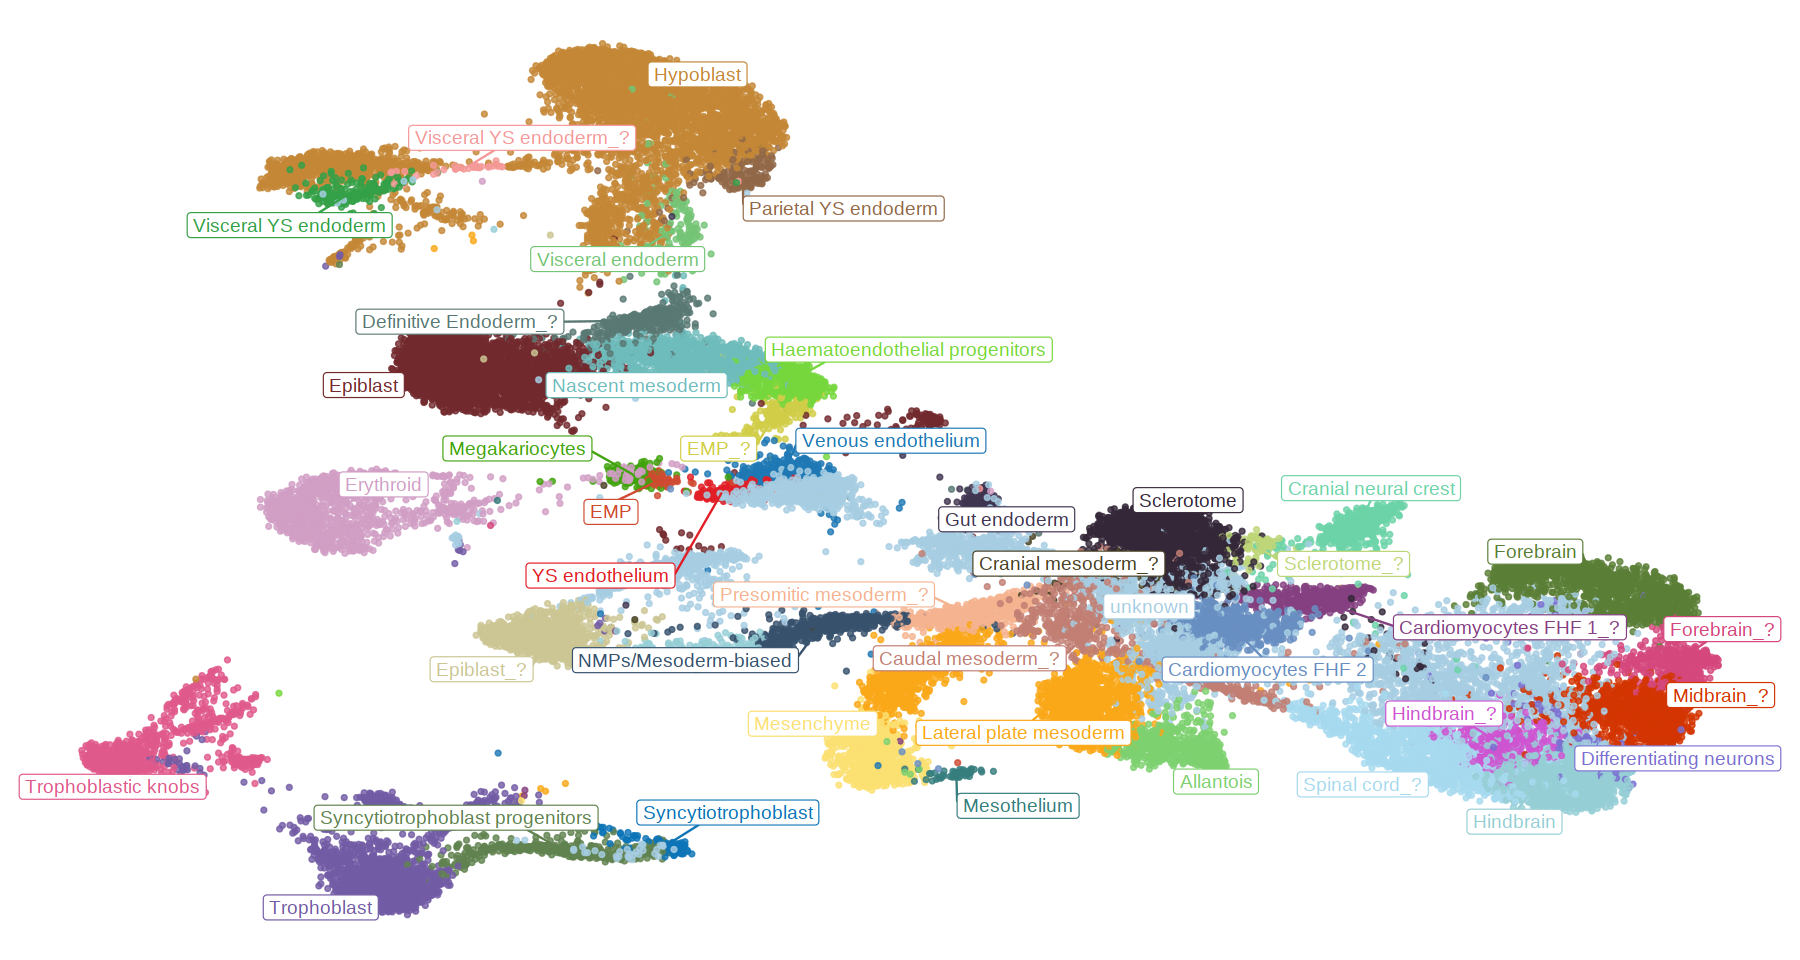

In [370]:
ggplot(to.plot, aes_string(x="umap1", y="umap2", color=colors)) +
    geom_point(size=1, alpha=0.8) + 
    scale_color_manual(values = as.vector(c(ArchRPalettes[[3]],ArchRPalettes[[5]], ArchRPalettes[[8]],ArchRPalettes[[9]]))[1:length(unique(to.plot[[colors]]))]) + 
    ggrepel::geom_label_repel(data=labels, 
                                aes_string('umap1', 'umap2', label=colors, color=colors), 
                                max.overlaps=Inf,
                                box.padding = 0.8) + 
    theme_void() + 
    theme(legend.position='none')

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]     chr9 37191805-37434390      + | ENSOCUG00000002190        MITF
  -------
  seqinfo: 22 sequences from an unspecified genome


2022-02-24 16:03:26 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Length of unique values greater than palette, interpolating..

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Length of unique values greater than palette, interpolating..

Warning message:
“Removed 42 rows containing missing values (position_stack).”
Picking joint bandwidth of 0.00549

Picking joint bandwidth of 0.00617

Picking joint bandwidth of 0.0259

Picking joint bandwidth of 0.00147

Picking joint bandwidth of 0.00156

Picking joint bandwidth of 0.00917

Picking joint bandwidth of 0.0251

Picking joint bandwidth of 0.016

Picking joint bandwidth of 0.0111

Picking joint bandwidth of 0.000114

Picking joint bandwidth of 0.00883

Picki

$MITF


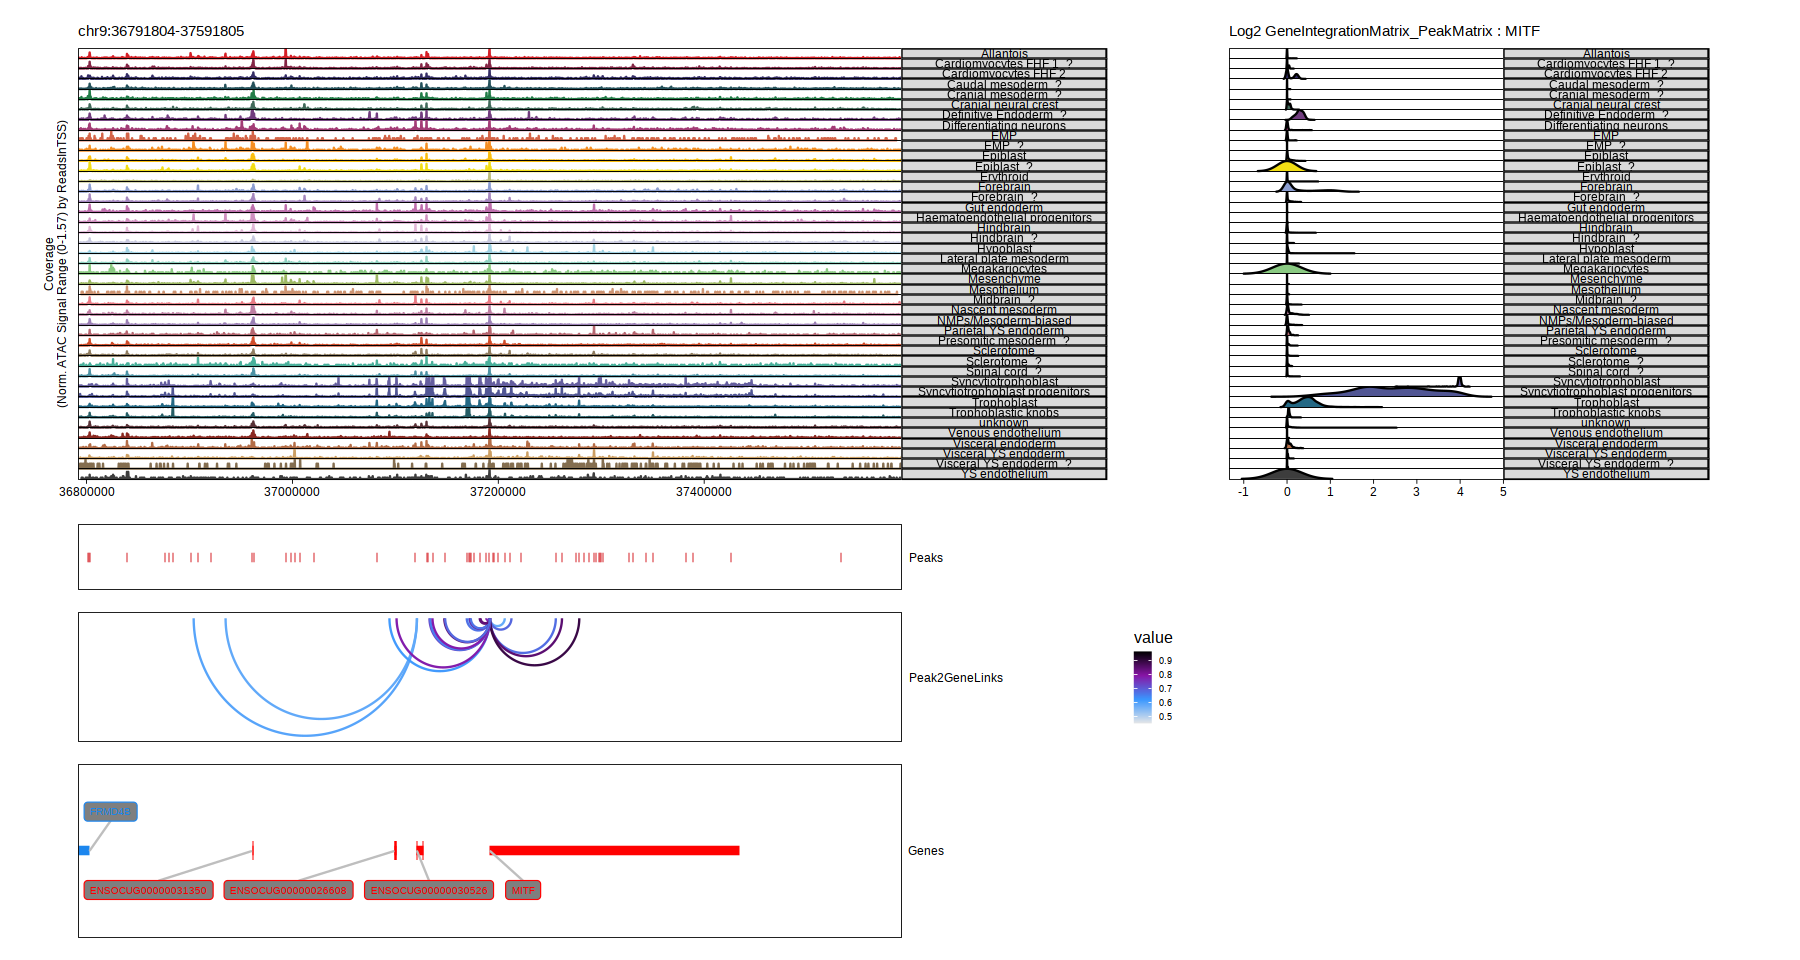

In [445]:
plotBrowserTrack(
        ArchRProj = ArchRProject, 
        groupBy = "celltype_v1", 
        geneSymbol = 'MITF', 
        upstream = 400000,
        downstream = 400000,
        useMatrix = 'GeneIntegrationMatrix_PeakMatrix',
        #useMatrix = 'GeneScoreMatrix', # For Gata1 this didn't look good, don't know why
        loops = getPeak2GeneLinks(ArchRProject, resolution = 100)
    ) 